In [86]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

In [87]:
def to_gray(img):
    if len(img.shape) == 3:
        return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img.copy()

def negative(img):
    return 255 - img

def log_transform(img):
    img_float = img.astype(float)
    c = 255.0 / np.log(1 + np.max(img_float))
    out = c * np.log(1 + img_float)
    return np.clip(out, 0, 255).astype(np.uint8)

def gamma_correction(img, gamma=0.4):
    img_float = img.astype(float) / 255.0
    out = np.power(img_float, gamma) * 255.0
    return np.clip(out, 0, 255).astype(np.uint8)

def noise_reducer(img):
    return cv2.medianBlur(img, 5)

In [88]:
def contrast_stretch(img):
    img_float = img.astype(float)
    min_val, max_val = np.min(img_float), np.max(img_float)

    if min_val == max_val:
        return img

    out = (img_float - min_val) / (max_val - min_val) * 255.0
    return np.clip(out, 0, 255).astype(np.uint8)

def threshold_grey(img, low=100, high=255):
    gray = to_gray(img)
    out = np.where((gray >= low) & (gray <= high), 255, 0)
    return out.astype(np.uint8)

In [89]:
def smooth_blur(img):
    img_float = img.astype(np.float32)
    kernel = np.ones((3, 3), np.float32) / 9.0
    out = cv2.filter2D(img_float, -1, kernel)
    return np.clip(out, 0, 255).astype(np.uint8)

def laplacian_sharpen(img):
    img_float = img.astype(np.float32)
    kernel = np.array([[-1, -1, -1],
                       [-1,  8, -1],
                       [-1, -1, -1]], dtype=np.float32)

    lap = cv2.filter2D(img_float, cv2.CV_32F, kernel)
    out = img_float + (0.2 * lap)
    return np.clip(out, 0, 255).astype(np.uint8)


--- Gambar ke-1 ---


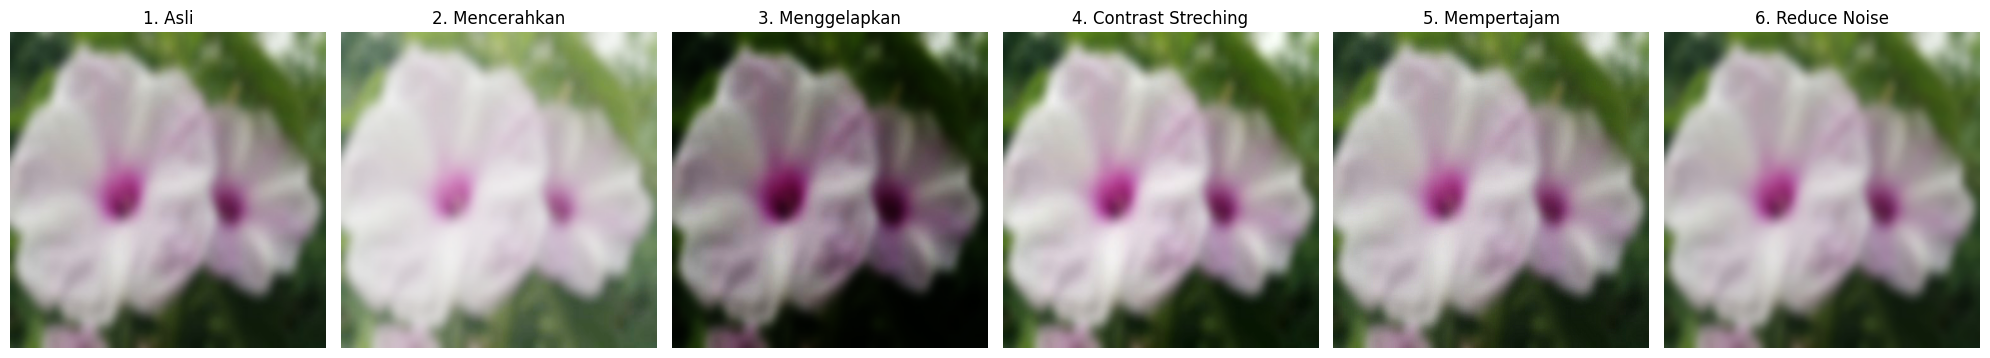


--- Gambar ke-2 ---


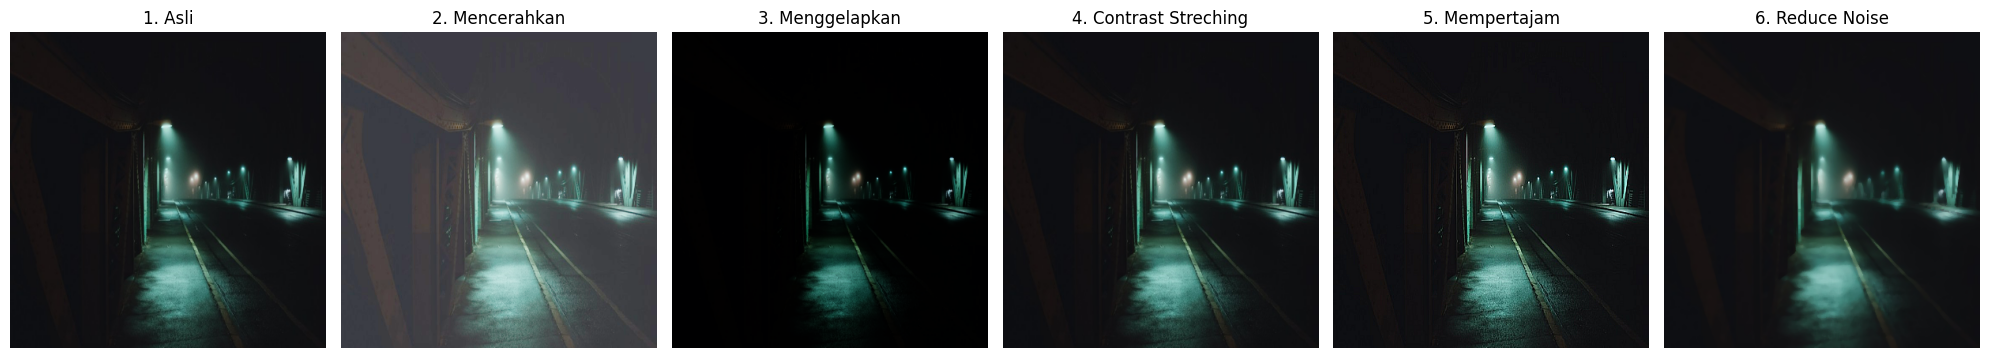


--- Gambar ke-3 ---


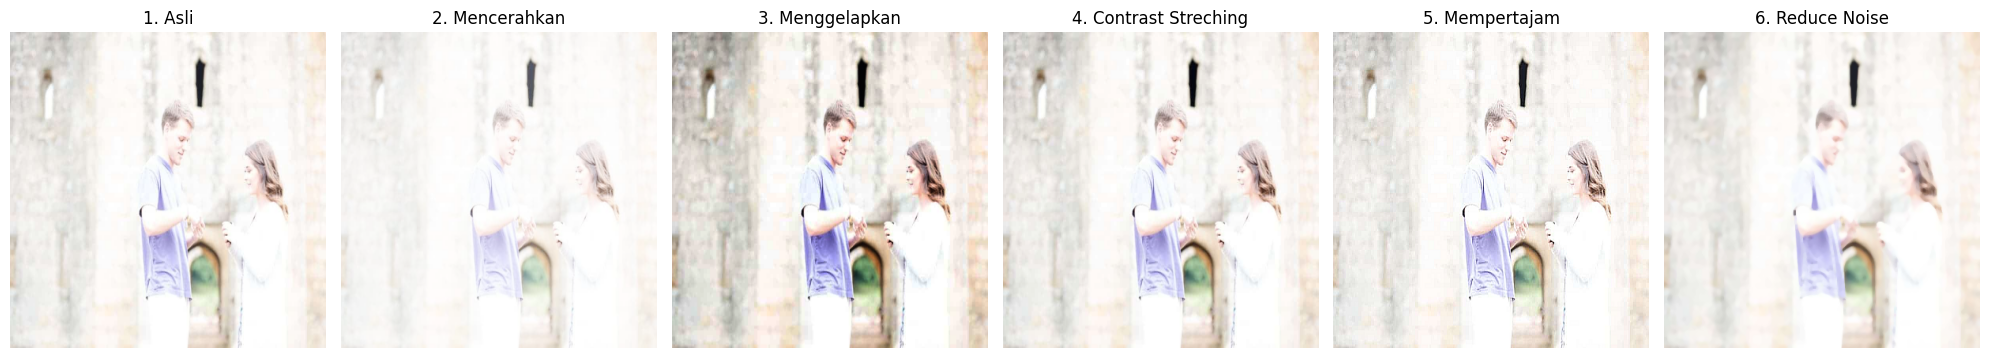


--- Gambar ke-4 ---


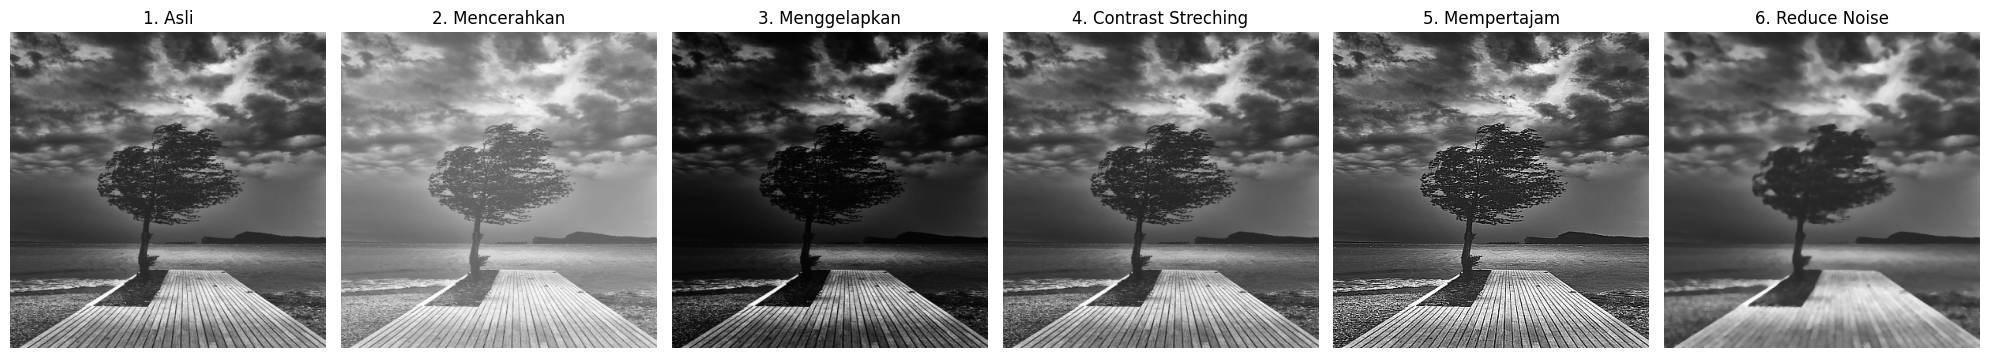


--- Gambar ke-5 ---


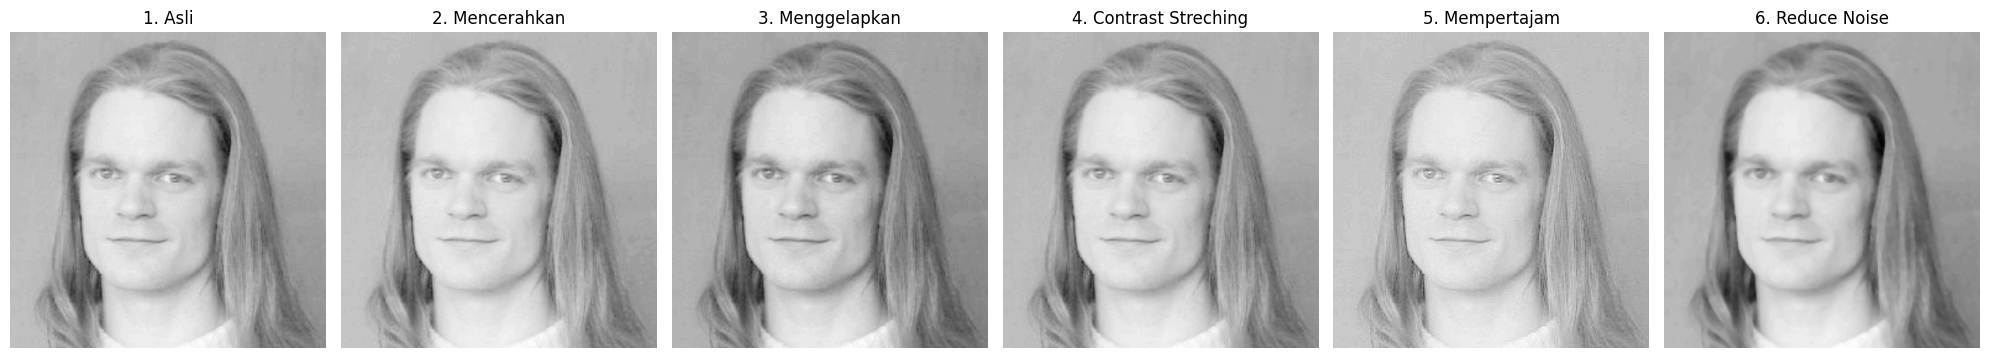


--- Gambar ke-6 ---


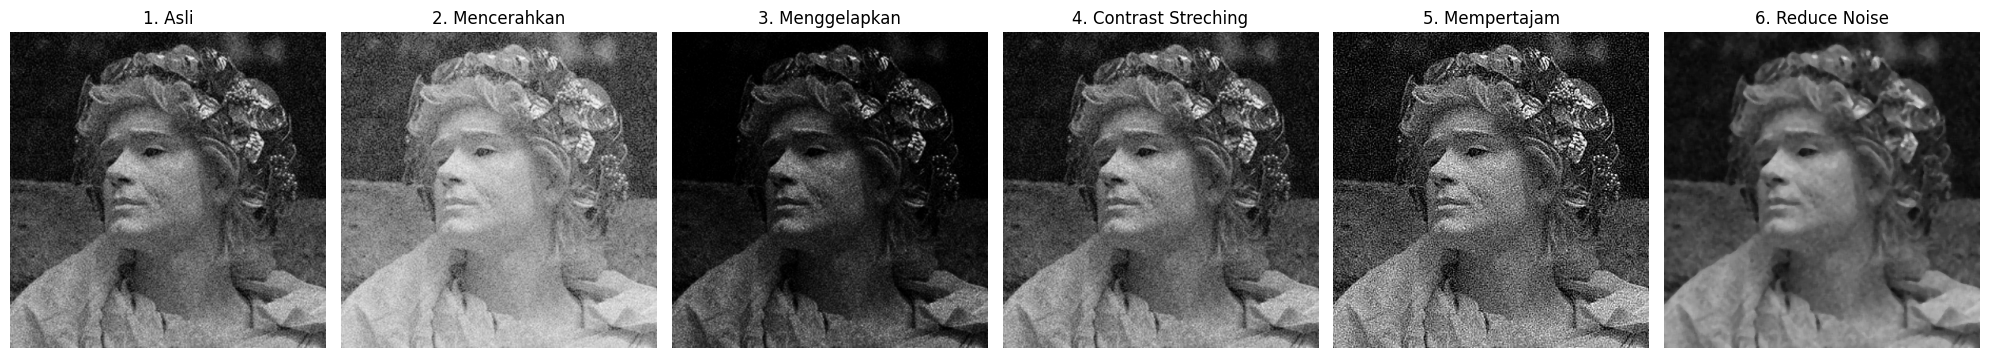

In [90]:
def tampilkan_gambar(judul, gambar):
    if len(gambar.shape) == 2:
        plt.imshow(gambar, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(gambar, cv2.COLOR_BGR2RGB))
    plt.title(judul)
    plt.axis('off')

def main_pipeline(url_gambar):
    try:
        file_id = re.search(r'/d/([a-zA-Z0-9_-]+)', url_gambar).group(1)
        download_url = f"https://drive.google.com/uc?export=download&id={file_id}"

        response = requests.get(download_url)
        response.raise_for_status()

        arr = np.asarray(bytearray(response.content), dtype=np.uint8)
        img_asli = cv2.imdecode(arr, -1)
    except Exception as e:
        print(f"Gagal mengunduh gambar: {e}")
        return

    # Rezise gambar agar mudah diproses
    img_asli = cv2.resize(img_asli, (400, 400))

    img_terang = gamma_correction(img_asli, gamma=0.5)
    img_gelap = gamma_correction(img_asli, gamma=2.0)
    img_kontras = contrast_stretch(img_asli)
    img_tajam = laplacian_sharpen(img_asli)
    img_noise = noise_reducer(img_asli)

    plt.figure(figsize=(20, 5))

    plt.subplot(1, 6, 1)
    tampilkan_gambar("1. Asli", img_asli)

    plt.subplot(1, 6, 2)
    tampilkan_gambar("2. Mencerahkan", img_terang)

    plt.subplot(1, 6, 3)
    tampilkan_gambar("3. Menggelapkan", img_gelap)

    plt.subplot(1, 6, 4)
    tampilkan_gambar("4. Contrast Streching", img_kontras)

    plt.subplot(1, 6, 5)
    tampilkan_gambar("5. Mempertajam", img_tajam)

    plt.subplot(1, 6, 6)
    tampilkan_gambar("6. Reduce Noise", img_noise)

    plt.tight_layout()
    plt.show()

images = [
    'https://drive.google.com/file/d/1DFdGTrXx3-An4PH2Zw7BG9fawZjheezT/view?usp=drive_link',
    'https://drive.google.com/file/d/1CJDnFQeZ2TQs6xgFWLkqKSf47o8y7vxR/view?usp=drive_link',
    'https://drive.google.com/file/d/1mwGTDmzTZ2jKSrSdgYgD246t7T6zu2ni/view?usp=drive_link',
    'https://drive.google.com/file/d/1pJG_CEj3bzPtXmZb7NUWc-_B79ntD3fE/view?usp=drive_link',
    'https://drive.google.com/file/d/1NT2gLxgw8DVPnE7DusOZ12RwqylU2zRH/view?usp=drive_link',
    'https://drive.google.com/file/d/1cOLfwTYrdA9lrmBlbI_1ZvOM82tjFmV4/view?usp=drive_link'
]

for indeks, url in enumerate(images, 1):
    print(f"\n--- Gambar ke-{indeks} ---")
    main_pipeline(url)